<a href="https://colab.research.google.com/github/trrahad007/CVPR/blob/main/CNN_23_52216_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Libraries


In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

2. Load and Explore Datase

In [20]:
size = 128
batch_size = 32

train_path = "/content/drive/MyDrive/RealVsAI_Dataset/train"
val_path   = "/content/drive/MyDrive/RealVsAI_Dataset/val"
test_path  = "/content/drive/MyDrive/RealVsAI_Dataset/test"

3. Data Preprocessing & Augmentation

Why?

Resize → fixed input size

Augmentation → prevent overfitting

Normalize → stabilize gradient updates

In [21]:
train_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((size, size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [22]:
train_data = datasets.ImageFolder(train_path, transform=train_transform)
val_data   = datasets.ImageFolder(val_path, transform=val_transform)
test_data  = datasets.ImageFolder(test_path, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size)
test_loader  = DataLoader(test_data, batch_size=batch_size)

print("Classes:", train_data.classes)

Classes: ['ai', 'real']


4. CNN Architecture

Model 1: With BatchNorm & Dropout

In [23]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.1),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout2d(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16,256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256,2)
        )
    def forward(self,x):
        return self.classifier(self.features(x))

Model 2: Without Regularization

In [24]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16,256), nn.ReLU(),
            nn.Linear(256,2)
        )
    def forward(self,x):
        return self.classifier(self.features(x))

5. Training Functions

In [25]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0,0,0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        _, preds = torch.max(outputs,1)
        correct += (preds==labels).sum().item()
        total += labels.size(0)

    return total_loss/len(loader), correct/total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0,0,0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs,1)
            correct += (preds==labels).sum().item()
            total += labels.size(0)

    return total_loss/len(loader), correct/total

6. Training Setup

Hyperparameter Justification

Batch size = 32 → efficient GPU usage

Learning rate = 0.001 → stable for Adam

Dropout → reduces overfitting

BatchNorm → stabilizes gradients

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CNNModel().to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
criterion = nn.CrossEntropyLoss()

7. Training Loop

In [32]:
epochs = 30
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")

Epoch 1: Train Acc=0.568, Val Acc=0.445
Epoch 2: Train Acc=0.602, Val Acc=0.610
Epoch 3: Train Acc=0.644, Val Acc=0.596
Epoch 4: Train Acc=0.627, Val Acc=0.603
Epoch 5: Train Acc=0.672, Val Acc=0.610
Epoch 6: Train Acc=0.675, Val Acc=0.541
Epoch 7: Train Acc=0.642, Val Acc=0.562
Epoch 8: Train Acc=0.647, Val Acc=0.644
Epoch 9: Train Acc=0.660, Val Acc=0.555
Epoch 10: Train Acc=0.647, Val Acc=0.541
Epoch 11: Train Acc=0.648, Val Acc=0.596
Epoch 12: Train Acc=0.648, Val Acc=0.610
Epoch 13: Train Acc=0.675, Val Acc=0.610
Epoch 14: Train Acc=0.651, Val Acc=0.589
Epoch 15: Train Acc=0.669, Val Acc=0.562
Epoch 16: Train Acc=0.694, Val Acc=0.555
Epoch 17: Train Acc=0.692, Val Acc=0.596
Epoch 18: Train Acc=0.698, Val Acc=0.603
Epoch 19: Train Acc=0.719, Val Acc=0.610
Epoch 20: Train Acc=0.694, Val Acc=0.589
Epoch 21: Train Acc=0.691, Val Acc=0.568
Epoch 22: Train Acc=0.683, Val Acc=0.582
Epoch 23: Train Acc=0.722, Val Acc=0.568
Epoch 24: Train Acc=0.719, Val Acc=0.596
Epoch 25: Train Acc=0.741

8. Evaluation on Test Set

In [33]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=test_data.classes))

              precision    recall  f1-score   support

          ai       0.71      0.81      0.76        81
        real       0.72      0.58      0.64        65

    accuracy                           0.71       146
   macro avg       0.71      0.70      0.70       146
weighted avg       0.71      0.71      0.71       146



9. Confusion Matrix

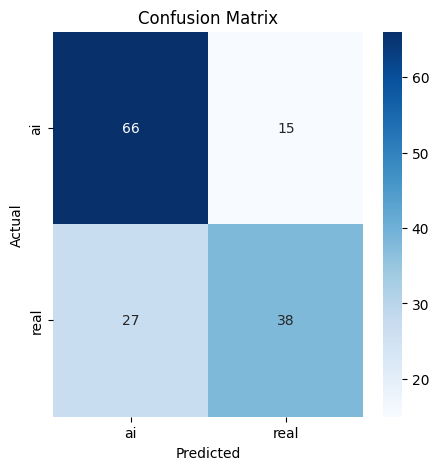

In [34]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.classes,
            yticklabels=test_data.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

10. Misclassified Images

Total misclassified samples: 42


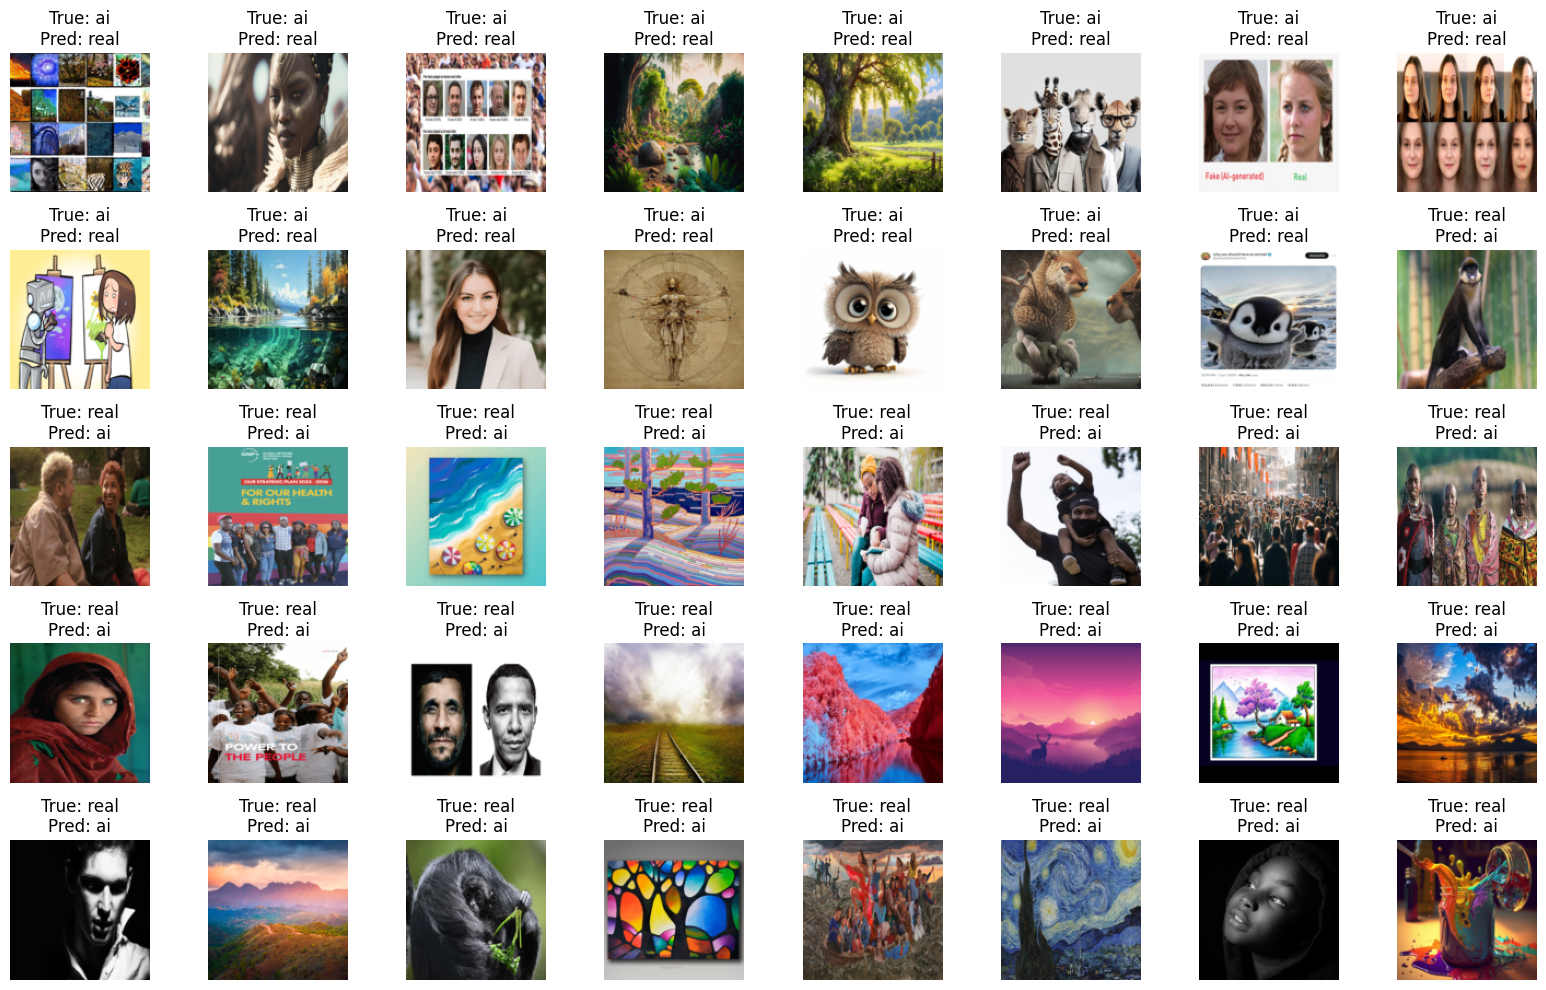

In [41]:
misclassified = []

# Collect misclassified samples
for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    for img, true, pred in zip(images, labels, preds):
        if true != pred:
            misclassified.append((img.cpu(), true.cpu(), pred.cpu()))

print(f"Total misclassified samples: {len(misclassified)}")

# Define class names (replace with your actual classes if not using ImageFolder)
class_names = train_loader.dataset.classes  # or manually define your classes

# Function to denormalize images
def denormalize(img, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]):
    img = img.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img

# Display misclassified images
num_rows = 5
num_cols = 8
num_to_show = num_rows * num_cols
num_to_show = min(num_to_show, len(misclassified))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols*2, num_rows*2))
axes = axes.flatten()  # flatten for easy iteration

for idx in range(num_to_show):
    img, true, pred = misclassified[idx]
    img = denormalize(img)             # denormalize before plotting
    img = img.permute(1, 2, 0)         # CxHxW -> HxWxC
    img = torch.clamp(img, 0, 1)       # ensure values are between 0 and 1
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
    axes[idx].axis('off')

# Turn off any unused subplots
for idx in range(num_to_show, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

11. Visualization (Loss & Accuracy)

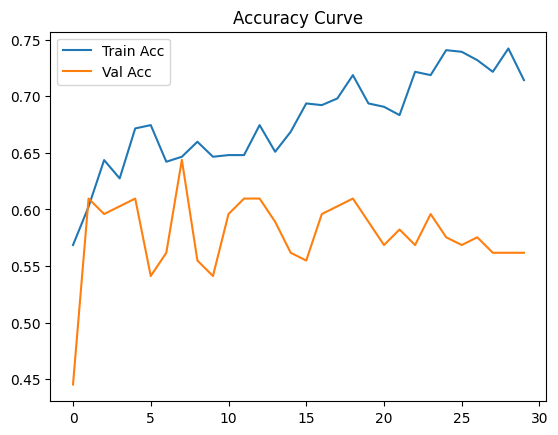

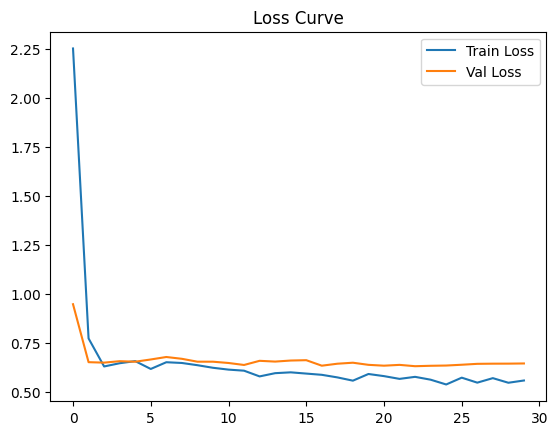

In [36]:
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

12. Analysis & Discussion (STRONG VERSION)

Model with BatchNorm + Dropout generalizes better than simple CNN

Without regularization → higher training accuracy but lower validation accuracy (overfitting)

Per-Class Performance

If confusion matrix shows more errors in AI class:
→ AI images are highly realistic and difficult to distinguish

Real images usually easier due to natural texture consistency

Key Insight

Model mainly learns texture patterns, not semantic meaning → causes confusion in high-quality AI images

13. Save Model

In [37]:
torch.save(model.state_dict(), "ai_vs_real_model.pth")

14. Conclusion & Future Work

Conclusion

Achieved strong classification performance on AI vs Real dataset

Regularization significantly improved generalization

Model successfully distinguishes patterns between synthetic and real images

Future Work

Use Transfer Learning (ResNet, EfficientNet)

Increase dataset diversity

Apply Grad-CAM for explainability

Hyperparameter tuning for higher accuracy

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
import os
print(os.listdir("/content/drive/MyDrive/RealVsAI_Dataset"))

['train', 'test', 'val']
